In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv - Sheet1.csv to dataset.csv - Sheet1 (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv - Sheet1.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (510, 5)


,EC (mg L-1),AV (V),SSA (m2 g-1),C (F g-1),SAC (mg g-1)
0,100,1.4,13.3,129.0,23.6
1,300,1.4,13.3,129.0,39.6
2,500,1.4,13.3,129.0,49.2
3,700,1.4,13.3,129.0,52.6
4,1000,1.4,13.3,129.0,53.7


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Columns:
['EC (mg L-1)', 'AV (V)', 'SSA (m2 g-1)', 'C (F g-1)', 'SAC (mg g-1)']

Missing values:
EC (mg L-1)     0
AV (V)          0
SSA (m2 g-1)    0
C (F g-1)       0
SAC (mg g-1)    0
dtype: int64

Duplicate rows:
0

Data types:
EC (mg L-1)       int64
AV (V)          float64
SSA (m2 g-1)    float64
C (F g-1)       float64
SAC (mg g-1)    float64
dtype: object


In [ ]:
X = df[
    [
        'C (F g-1)',
        'SSA (m2 g-1)',
        'EC (mg L-1)',
        'AV (V)'
    ]
]

y = df['SAC (mg g-1)']

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input features:
['C (F g-1)', 'SSA (m2 g-1)', 'EC (mg L-1)', 'AV (V)']

Target:
SAC (mg g-1)

X shape: (510, 4)
y shape: (510,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 408
Testing samples: 102


In [ ]:
!pip install -q xgboost lightgbm catboost ngboost

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from ngboost import NGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost trained successfully!")
print("First 10 predictions:")
print(y_pred_xgb[:10])

XGBoost trained successfully!
First 10 predictions:
[ 20.536034  26.734474  53.55603   32.00965   29.096136  32.72125
 102.494774  61.185307  49.54256   59.13489 ]


In [ ]:
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM trained successfully!")
print("First 10 predictions:")
print(y_pred_lgbm[:10])

LightGBM trained successfully!
First 10 predictions:
[24.07507067 31.24513568 51.57743231 39.67973742 29.26583754 34.55327911
 88.43270525 66.87919946 51.36746082 55.28218812]


In [ ]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

print("CatBoost trained successfully!")
print("First 10 predictions:")
print(y_pred_cat[:10])

CatBoost trained successfully!
First 10 predictions:
[21.31521394 32.05262885 39.85125282 36.16760568 28.52045574 37.0593518
 94.92019997 62.3620706  50.57474818 52.51643833]


In [ ]:
ngb = NGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=False
)

ngb.fit(X_train, y_train)

y_pred_ngb = ngb.predict(X_test)

print("NGBoost trained successfully!")
print("First 10 predictions:")
print(y_pred_ngb[:10])

NGBoost trained successfully!
First 10 predictions:
[19.89241977 32.20679763 45.1064998  35.97470191 31.69436149 32.26201411
 91.72567307 62.96230045 55.42452895 55.40552762]


In [ ]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return [name, mae, mse, rmse]


modern_results = pd.DataFrame([
    evaluate_model("XGBoost", y_test, y_pred_xgb),
    evaluate_model("LightGBM", y_test, y_pred_lgbm),
    evaluate_model("CatBoost", y_test, y_pred_cat),
    evaluate_model("NGBoost", y_test, y_pred_ngb)
], columns=["Model", "MAE", "MSE", "RMSE"])

modern_results = modern_results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    modern_results.style.format({
        "MAE": "{:.3f}",
        "MSE": "{:.3f}",
        "RMSE": "{:.3f}"
    })
)

,Model,MAE,MSE,RMSE
0,XGBoost,5.816,65.269,8.079
1,NGBoost,6.845,80.084,8.949
2,CatBoost,6.924,83.767,9.152
3,LightGBM,7.097,92.397,9.612


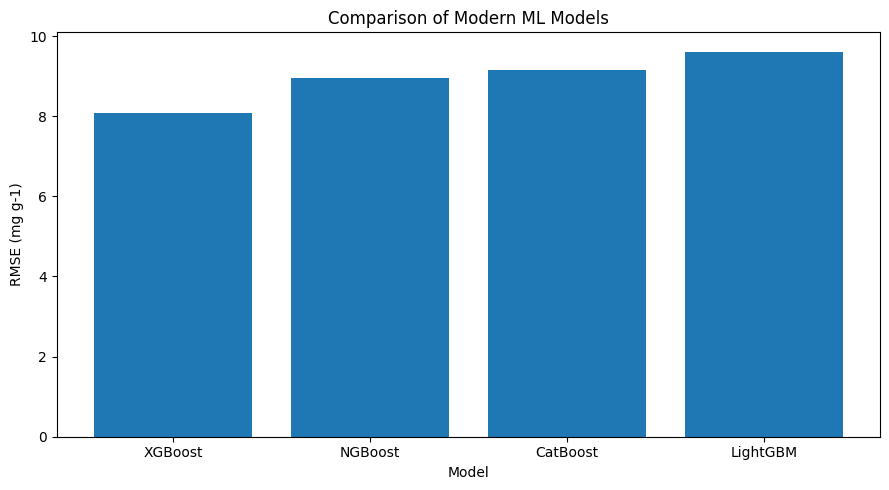

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    modern_results["Model"],
    modern_results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE (mg g-1)")
plt.title("Comparison of Modern ML Models")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat,
    "NGBoost": ngb
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    cv_results.append([
        name,
        -scores.mean(),
        scores.std()
    ])

cv_results = pd.DataFrame(
    cv_results,
    columns=["Model", "Mean CV RMSE", "Std CV RMSE"]
)

display(
    cv_results.style.format({
        "Mean CV RMSE": "{:.3f}",
        "Std CV RMSE": "{:.3f}"
    })
)

,Model,Mean CV RMSE,Std CV RMSE
0,XGBoost,8.794,1.720
1,LightGBM,11.999,1.566
2,CatBoost,10.258,1.349
3,NGBoost,9.901,1.430


In [ ]:
best_two = modern_results.head(2)

print("Top 2 models:")
display(best_two)

Top 2 models:


,Model,MAE,MSE,RMSE
0,XGBoost,5.816271,65.268548,8.078895
1,NGBoost,6.845255,80.084169,8.948976


In [ ]:
modern_results = modern_results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    modern_results.style.format({
        "MAE": "{:.3f}",
        "MSE": "{:.3f}",
        "RMSE": "{:.3f}"
    })
)

,Model,MAE,MSE,RMSE
0,XGBoost,5.816,65.269,8.079
1,NGBoost,6.845,80.084,8.949
2,CatBoost,6.924,83.767,9.152
3,LightGBM,7.097,92.397,9.612


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat,
    "NGBoost": ngb
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    cv_results.append([
        name,
        -scores.mean(),
        scores.std()
    ])

cv_results = pd.DataFrame(
    cv_results,
    columns=["Model", "Mean CV RMSE", "Std CV RMSE"]
)

display(
    cv_results.style.format({
        "Mean CV RMSE": "{:.3f}",
        "Std CV RMSE": "{:.3f}"
    })
)

,Model,Mean CV RMSE,Std CV RMSE
0,XGBoost,8.794,1.720
1,LightGBM,11.999,1.566
2,CatBoost,10.258,1.349
3,NGBoost,9.892,1.433


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print("Best CV RMSE:",
      np.sqrt(-xgb_grid.best_score_))

Best XGBoost parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE: 7.839613225310226


In [ ]:
from lightgbm import LGBMRegressor

lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'num_leaves': [7, 15, 31],
    'min_child_samples': [5, 10, 20]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(
        random_state=42,
        verbosity=-1
    ),
    lgbm_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

lgbm_grid.fit(X_train, y_train)

print("Best LightGBM parameters:")
print(lgbm_grid.best_params_)

print("Best CV RMSE:",
      np.sqrt(-lgbm_grid.best_score_))

Best LightGBM parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 5, 'n_estimators': 300, 'num_leaves': 15}
Best CV RMSE: 9.282019390888415


In [ ]:
from catboost import CatBoostRegressor

cat_param_grid = {
    'iterations': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 4, 5, 6],
    'l2_leaf_reg': [1, 3, 5, 10]
}

cat_grid = GridSearchCV(
    CatBoostRegressor(
        random_seed=42,
        verbose=False
    ),
    cat_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)

print("Best CatBoost parameters:")
print(cat_grid.best_params_)

print("Best CV RMSE:",
      np.sqrt(-cat_grid.best_score_))

Best CatBoost parameters:
{'depth': 6, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best CV RMSE: 8.682604400971774


In [ ]:
from ngboost import NGBRegressor

ngb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'minibatch_frac': [1.0, 0.8]
}

ngb_grid = GridSearchCV(
    NGBRegressor(
        random_state=42,
        verbose=False
    ),
    ngb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ngb_grid.fit(X_train, y_train)

print("Best NGBoost parameters:")
print(ngb_grid.best_params_)

print("Best CV RMSE:",
      np.sqrt(-ngb_grid.best_score_))

Best NGBoost parameters:
{'learning_rate': 0.1, 'minibatch_frac': 0.8, 'n_estimators': 500}
Best CV RMSE: 8.309806947561032


In [ ]:
best_xgb = xgb_grid.best_estimator_
best_lgbm = lgbm_grid.best_estimator_
best_cat = cat_grid.best_estimator_
best_ngb = ngb_grid.best_estimator_

pred_xgb_tuned = best_xgb.predict(X_test)
pred_lgbm_tuned = best_lgbm.predict(X_test)
pred_cat_tuned = best_cat.predict(X_test)
pred_ngb_tuned = best_ngb.predict(X_test)

tuned_results = pd.DataFrame([
    evaluate_model(
        "Tuned XGBoost",
        y_test,
        pred_xgb_tuned
    ),
    evaluate_model(
        "Tuned LightGBM",
        y_test,
        pred_lgbm_tuned
    ),
    evaluate_model(
        "Tuned CatBoost",
        y_test,
        pred_cat_tuned
    ),
    evaluate_model(
        "Tuned NGBoost",
        y_test,
        pred_ngb_tuned
    )
], columns=["Model", "MAE", "MSE", "RMSE"])

tuned_results = tuned_results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    tuned_results.style.format({
        "MAE": "{:.3f}",
        "MSE": "{:.3f}",
        "RMSE": "{:.3f}"
    })
)

,Model,MAE,MSE,RMSE
0,Tuned CatBoost,5.110,56.282,7.502
1,Tuned XGBoost,5.524,58.596,7.655
2,Tuned LightGBM,5.384,64.679,8.042
3,Tuned NGBoost,5.675,65.534,8.095


In [ ]:
import shap
import numpy as np
import pandas as pd


explainer_cat = shap.TreeExplainer(best_cat)


shap_values_cat = explainer_cat.shap_values(X_test)

print("SHAP values calculated successfully!")
print("Shape:", shap_values_cat.shape)

SHAP values calculated successfully!
Shape: (102, 4)


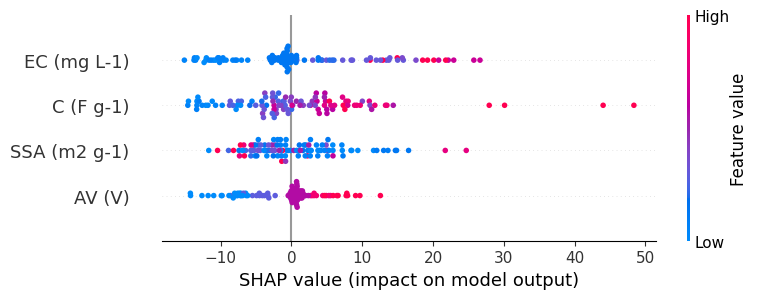

In [ ]:
shap.summary_plot(
    shap_values_cat,
    X_test,
    feature_names=X.columns
)

In [ ]:
cat_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': np.abs(shap_values_cat).mean(axis=0)
})

cat_feature_importance = cat_feature_importance.sort_values(
    'Mean Absolute SHAP',
    ascending=False
).reset_index(drop=True)

display(
    cat_feature_importance.style.format({
        'Mean Absolute SHAP': '{:.3f}'
    })
)

,Feature,Mean Absolute SHAP
0,EC (mg L-1),7.451
1,C (F g-1),7.051
2,SSA (m2 g-1),5.027
3,AV (V),3.922


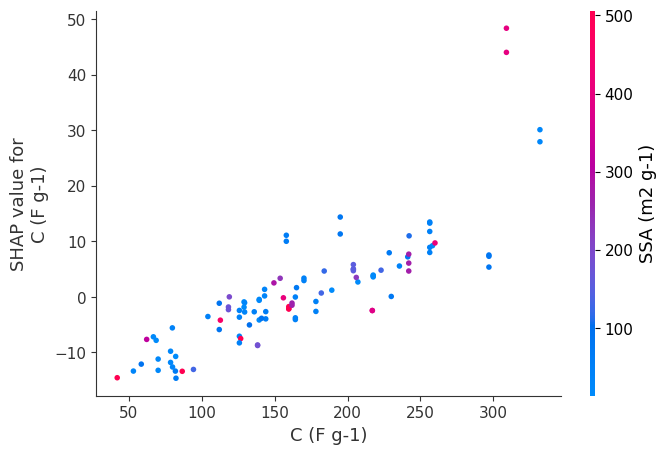

In [ ]:
shap.dependence_plot(
    'C (F g-1)',
    shap_values_cat,
    X_test
)

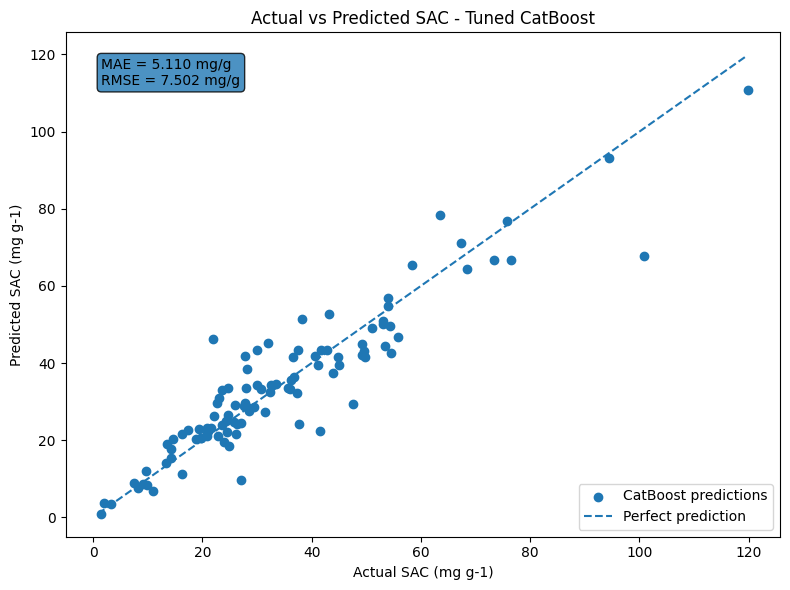

CatBoost MAE : 5.11
CatBoost MSE : 56.282
CatBoost RMSE: 7.502


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


mae_cat = mean_absolute_error(y_test, pred_cat_tuned)
mse_cat = mean_squared_error(y_test, pred_cat_tuned)
rmse_cat = np.sqrt(mse_cat)


plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    pred_cat_tuned,
    label="CatBoost predictions"
)


min_val = min(y_test.min(), pred_cat_tuned.min())
max_val = max(y_test.max(), pred_cat_tuned.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    label="Perfect prediction"
)


plt.text(
    0.05, 0.95,
    f"MAE = {mae_cat:.3f} mg/g\nRMSE = {rmse_cat:.3f} mg/g",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', alpha=0.8)
)

plt.xlabel("Actual SAC (mg g-1)")
plt.ylabel("Predicted SAC (mg g-1)")
plt.title("Actual vs Predicted SAC - Tuned CatBoost")

plt.legend()
plt.tight_layout()
plt.show()

print("CatBoost MAE :", round(mae_cat, 3))
print("CatBoost MSE :", round(mse_cat, 3))
print("CatBoost RMSE:", round(rmse_cat, 3))